In [59]:
from hossam import load_data
from pandas import DataFrame, get_dummies
from matplotlib import pyplot as plt
from matplotlib import dates
from matplotlib import font_manager as fm 
import seaborn as sb
import numpy as np
import statsmodels.api as sm
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

In [60]:
my_dpi = 200
my_font_name = "./NotoSansKr-Regular.ttf"
fm.fontManager.addfont(fpath)
fprop = fm.FontProperties(fname=fpath)
fname = fprop.get_name()
plt.rcParams['font.family'] = fname
plt.rcParams['font.size'] = 6
plt.rcParams['axes.unicode_minus'] = False

차분 처리 함수

In [61]:
def diff(df, yname):
    diff_df = df.copy()
    diff_count = 0      # 몇 번까지 차분을 수행했는지 count
    result = []         # 결과를 저장할 리스트

    while True:
        ar = adfuller(diff_df[yname])

        ar_dict = {
            "차수": diff_count,
            "ADF Statistic": ar[0],
            "p-value": ar[1],
            "result": True if ar[1] <= 0.05 else False,
        }

        # 리스트에 정상성 검사 결과 저장
        result.append(ar_dict)

        # 정상성 충족 시 반복 종료
        if ar_dict["result"]:
            break

        # 정상성이 충족되지 않았다면 차분 수행 후 다시 실행
        diff_count += 1
        diff_df = diff_df.diff().dropna()

    return DataFrame(result), diff_df


ACF-PACF일괄 처리

In [62]:
def acf_pacf(df, yname, threshold=0.05):
    # ==============================
    # ACF
    # ==============================
    acf_vals = acf(df[yname])
    acf_threshold = 2 / np.sqrt(len(df[yname]))

    df_acf = DataFrame({
        "lag": np.arange(len(acf_vals)),
        "acf": acf_vals,
    })

    df_acf["abs_acf"] = df_acf["acf"].abs()
    df_acf["significant"] = df_acf["abs_acf"] > acf_threshold

    df_acf["acf"] = df_acf["acf"].round(3)
    df_acf["abs_acf"] = df_acf["abs_acf"].round(3)
    df_acf["threshold"] = round(acf_threshold, 3)

    df_acf_result = (
        df_acf
        .query("lag > 0")
        .reset_index(drop=True)
    )

    df_acf_result["prev_significant"] = df_acf_result["significant"].shift(1)

    df_acf_result["cut_candidate"] = (
        (df_acf_result["prev_significant"] == True) &
        (df_acf_result["significant"] == False)
    )

    q_candidate = (
        df_acf_result
        .loc[df_acf_result["cut_candidate"], "lag"]
        .min()
    )

    # ==============================
    # PACF
    # ==============================
    pacf_vals = pacf(df[yname])
    pacf_threshold = 2 / np.sqrt(len(df[yname]))

    df_pacf = DataFrame({
        "lag": np.arange(len(pacf_vals)),
        "pacf": pacf_vals,
    })

    df_pacf["abs_pacf"] = df_pacf["pacf"].abs()
    df_pacf["significant"] = df_pacf["abs_pacf"] > pacf_threshold

    df_pacf["pacf"] = df_pacf["pacf"].round(3)
    df_pacf["abs_pacf"] = df_pacf["abs_pacf"].round(3)
    df_pacf["threshold"] = round(pacf_threshold, 3)

    df_pacf_result = (
        df_pacf
        .query("lag > 0")
        .reset_index(drop=True)
    )

    df_pacf_result["prev_significant"] = df_pacf_result["significant"].shift(1)

    df_pacf_result["cut_candidate"] = (
        (df_pacf_result["prev_significant"] == True) &
        (df_pacf_result["significant"] == False)
    )

    p_candidate = (
        df_pacf_result
        .loc[df_pacf_result["cut_candidate"], "lag"]
        .min()
    )

    return p_candidate, q_candidate


ARIMA 수행 함수

In [63]:
def arima(df, yname, p, d, q, s=None):
    # NaN 입력 시 기본값 처리
    p = 0 if np.isnan(p) else p
    d = 0 if np.isnan(d) else d
    q = 0 if np.isnan(q) else q
    s = 0 if (s is None or np.isnan(s)) else s

    results = []   # 결과 저장용 리스트

    for x in range(0, p + 1):
        for y in range(0, d + 1):
            for z in range(0, q + 1):
                try:
                    if s == 0:
                        print(f"(p,d,q)=({x},{y},{z})")
                        model = ARIMA(
                            df[yname],
                            order=(x, y, z)
                        )
                    else:
                        print(f"(p,d,q,s)=({x},{y},{z},{s})")
                        model = ARIMA(
                            df[yname],
                            order=(x, y, z),
                            seasonal_order=(x, y, z, s)
                        )

                    fit = model.fit()

                    # 수렴 실패 모델 제거
                    if not fit.mle_retvals.get("converged", False):
                        continue

                    results.append({
                        "p": x,
                        "d": y,
                        "q": z,
                        "AIC": fit.aic,
                        "BIC": fit.bic,
                    })

                except Exception:
                    # 수렴 실패 / 모델 오류 건너뜀
                    continue

    df_results = DataFrame(results)

    best_model = (
        df_results
        .sort_values(["BIC", "AIC"])
        .iloc[0]
    )

    return df_results, best_model

ARIMA 결과 해석 함수

In [64]:
def arima_report(fit, data, threshold=0.05):
    """
    SARIMAXResults 객체(fit)와 원본 데이터(data)를 받아
    모델 적합도 요약(cdf),
    계수 요약(rdf),
    결과 요약(result_report),
    모델 평가(model_report),
    계수별 해석(variable_reports)
    를 반환한다.
    """

    # ==============================
    # 모델 적합도 요약
    # ==============================
    cdf = DataFrame({
        "Log Likelihood": [fit.llf],
        "AIC": [fit.aic],
        "BIC": [fit.bic],
        "HQIC": [fit.hqic],
        "관측치 수": [fit.nobs],
    })

    # ==============================
    # 계수 테이블 구성
    # ==============================
    params = fit.params
    bse = fit.bse
    zvals = params / bse
    pvals = fit.pvalues
    conf = fit.conf_int()

    rows = []

    for name in params.index:
        p = pvals[name]

        stars = (
            "***" if p < 0.001 else
            "**" if p < 0.01 else
            "*" if p < 0.05 else
            ""
        )

        rows.append({
            "변수": name,
            "계수": params[name],
            "표준오차": bse[name],
            "z": f"{zvals[name]:.3f}{stars}",
            "p-value": p,
            "CI_lower": conf.loc[name, 0],
            "CI_upper": conf.loc[name, 1],
        })

    rdf = DataFrame(rows)

    # ==============================
    # 결과 요약
    # ==============================
    result_report = {
        "Log Likelihood": round(fit.llf, 3),
        "AIC": round(fit.aic, 3),
        "BIC": round(fit.bic, 3),
    }

    # ==============================
    # 모델 진단 (Ljung-Box)
    # ==============================
    lb_test = fit.test_serial_correlation(method="ljungbox")
    lb_pvalue = lb_test[1][-1]

    if lb_pvalue > threshold:
        model_report = (
            f"ARIMA{fit.model.order}{fit.model.seasonal_order} 모델은 "
            f"AIC={fit.aic:.3f}, BIC={fit.bic:.3f}이며 "
            "잔차의 자기상관은 Ljung-Box 검정에서 유의하지 않았다."
        )
    else:
        model_report = (
            f"ARIMA{fit.model.order}{fit.model.seasonal_order} 모델은 "
            f"AIC={fit.aic:.3f}, BIC={fit.bic:.3f}이나 "
            "잔차의 자기상관이 Ljung-Box 검정에서 유의하다."
        )

    # ==============================
    # 계수별 해석 문장 (시계열 해석 포함)
    # ==============================
    variable_reports = []

    for _, row in rdf.iterrows():
        name = row["변수"]

        if name == "const":
            continue

        coef = row["계수"]
        pval = row["p-value"]

        # 변수 의미 해석
        if name.startswith("ar.S"):
            meaning = "계절 AR 성분이 현재 값에 미치는 영향"
        elif name.startswith("ar."):
            meaning = "과거 값이 현재 값에 미치는 영향"
        elif name.startswith("ma.S"):
            meaning = "계절 MA 성분이 오차에 미치는 영향"
        elif name.startswith("ma."):
            meaning = "과거 오차가 현재 값에 미치는 영향"
        else:
            meaning = "시계열의 구조적 요소"

        # 방향성
        if coef > 0:
            direction = "양(+)의 방향"
        elif coef < 0:
            direction = "음(-)의 방향"
        else:
            direction = "뚜렷한 방향성 없음"

        # 통계적 유의성
        if pval < threshold:
            stat_text = "통계적으로 유의함"
            plain_text = "우연이 아닌 구조적 패턴일 가능성이 높다"
        else:
            stat_text = "통계적으로 유의하지 않음"
            plain_text = "우연에 의해 나타났을 가능성을 배제하기 어렵다"

        variable_reports.append(
            f"[{name}] 계수={coef:.3f} → {stat_text} "
            f"(p={pval:.3f}, 기준={threshold}). "
            f"{meaning}이며 {direction}으로 작용한다. "
            f"{plain_text}."
        )

    return cdf, rdf, result_report, model_report, variable_reports


📘문제1

In [65]:
origin = load_data('temperatures_seoul')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab13_/temperatures_seoul.xlsx
[desc] 1973년 1월부터 2023년 8월까지 서울의 월평균 기온 데이터 (출처: 기상청)
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (602, 2)
열 개수: 2
행 개수: 602

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602 entries, 0 to 601
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   날짜       602 non-null    datetime64[ns]
 1   평균기온(℃)  602 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 9.5 KB
None


,날짜,평균기온(℃)
0,1973-07-01,26.816129
1,1973-08-01,25.883871
2,1973-09-01,20.323333
3,1973-10-01,13.038710
4,1973-11-01,4.723333


📝시계열 인덱스 설정

In [66]:
df = origin.set_index("날짜")
df = df.asfreq('MS')
df.head()

,평균기온(℃)
날짜,
1973-07-01,26.816129
1973-08-01,25.883871
1973-09-01,20.323333
1973-10-01,13.038710
1973-11-01,4.723333


📝차분

In [67]:
yname = '평균기온(℃)'
adf, diff_df = diff(df,yname)
display(adf)
display(diff_df)

,차수,ADF Statistic,p-value,result
0,0,-3.877408,0.002208,True


,평균기온(℃)
날짜,
1973-07-01,26.816129
1973-08-01,25.883871
1973-09-01,20.323333
1973-10-01,13.038710
1973-11-01,4.723333
...,...
2023-04-01,13.800000
2023-05-01,19.522581
2023-06-01,23.383333


📝차분 회수 구하기

In [68]:
d = adf[adf['result']]['차수'].min()
d

np.int64(0)

📝차분 결과 시각화

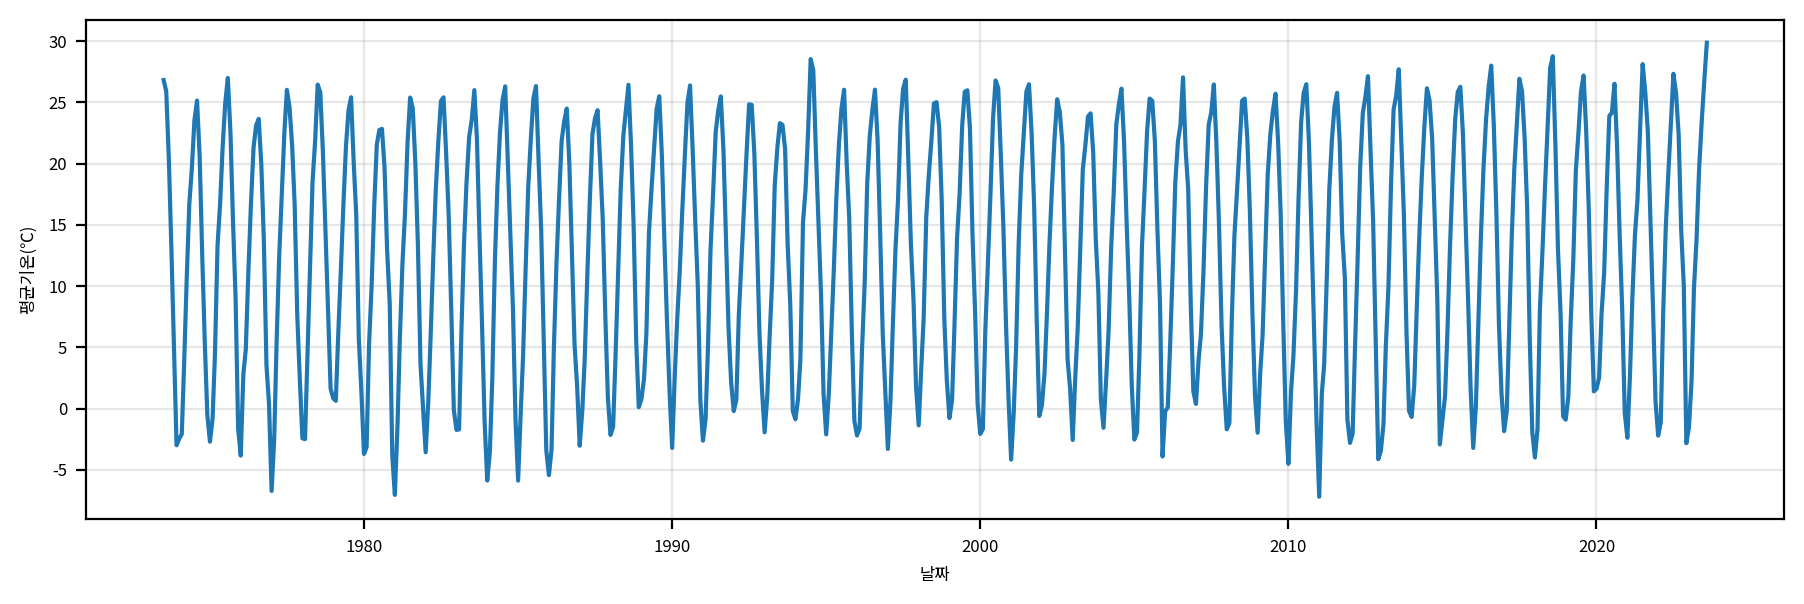

In [69]:
width_px = 1800
height_px = 600
rows = 1
cols=1
figsize = (width_px /my_dpi, height_px/my_dpi)
fig, ax = plt.subplots(rows,cols,figsize=figsize, dpi=my_dpi)

# 그래프 그리기->seaborn 사용
sb.lineplot(data=diff_df, x=diff_df.index, y=yname)


ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

📝ACF,PACF

In [70]:
def acf_pacf(df, col):
    fig, axes = plt.subplots(2, 1, figsize=(12, 6))

    plot_acf(df[col], ax=axes[0], lags=40)
    plot_pacf(df[col], ax=axes[1], lags=40, method='ywm')

    plt.tight_layout()
    plt.show()   # 🔴 이게 없으면 안 나옴

    return p, q


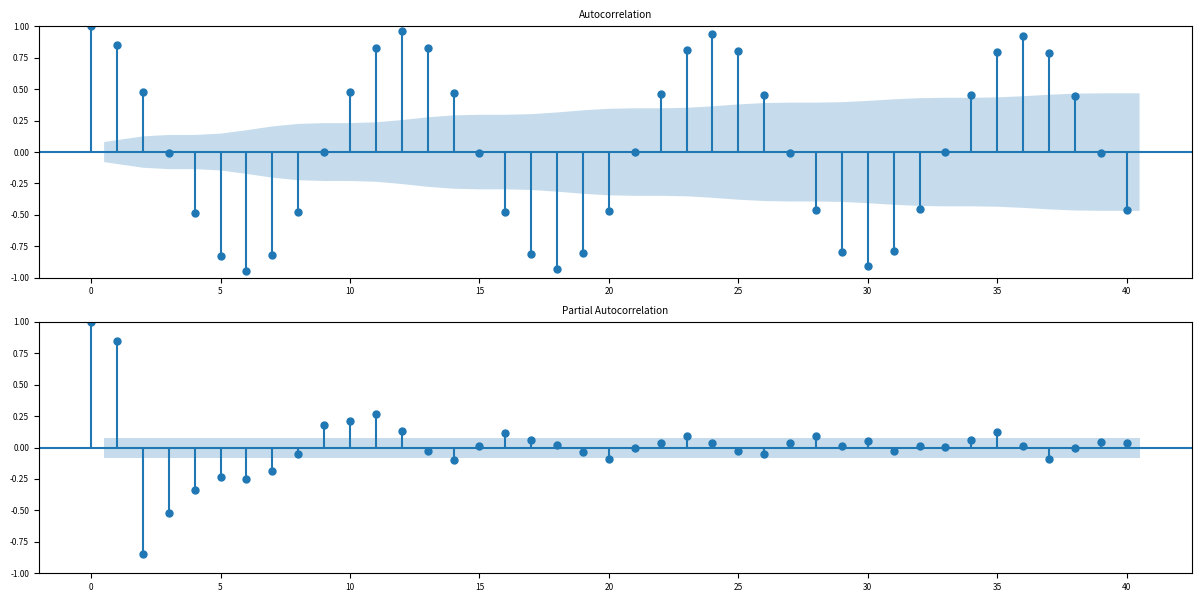

p=16, q=29


In [71]:
p, q = acf_pacf(diff_df,'평균기온(℃)' )
print(f"p={p}, q={q}")

📘문제2

In [72]:
origin = load_data('born_baby')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab13_/born_baby.xlsx
[desc] 2000년 1월부터 2022년 12월까지 시단위 출생자 수 (출처: 국가통계포털)
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (276, 18)
열 개수: 18
행 개수: 276

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   시점       276 non-null    object
 1   서울특별시    276 non-null    int64 
 2   부산광역시    276 non-null    int64 
 3   대구광역시    276 non-null    int64 
 4   인천광역시    276 non-null    int64 
 5   광주광역시    276 non-null    int64 
 6   대전광역시    276 non-null    int64 
 7   울산광역시    276 non-null    int64 
 8   세종특별자치시  276 non-null    int64 
 9   경기도      276 non-null    int64 
 10  강원도      276 non-null    int64 
 11  충청북도     276 non-null    int64 
 12  충청남도     276 non-null    int64 
 13  전라북도     276 non-null    int64 
 14  전라남도     276 non-null    int64 
 15  경상북도     276 non-null    int64 
 16  경상남도     2

,시점,서울특별시,부산광역시,대구광역시,인천광역시,광주광역시,대전광역시,울산광역시,세종특별자치시,경기도,강원도,충청북도,충청남도,전라북도,전라남도,경상북도,경상남도,제주특별자치도
0,2000년 01월,12866,3752,3057,3320,2159,1859,1479,0,13527,1966,1903,2398,2547,2679,3362,3928,842
1,2000년 02월,11797,3632,2698,3069,1916,1752,1388,0,12437,1780,1722,2273,2296,2366,3221,3612,764
2,2000년 03월,12453,3935,3057,3267,1893,1835,1524,0,13157,1803,1805,2269,2384,2423,3292,3972,809
3,2000년 04월,10782,3464,2753,2683,1773,1690,1360,0,11698,1612,1647,2076,2054,2157,2968,3661,680
4,2000년 05월,10817,3511,2785,2782,1698,1599,1311,0,11362,1615,1652,1988,2041,2109,2973,3516,733


📝시계열 데이터 타입 변환

In [73]:
from pandas import to_datetime
df = origin.copy()
df['시점'] = to_datetime(df['시점'], format="%Y년 %m월")
df.head()

,시점,서울특별시,부산광역시,대구광역시,인천광역시,광주광역시,대전광역시,울산광역시,세종특별자치시,경기도,강원도,충청북도,충청남도,전라북도,전라남도,경상북도,경상남도,제주특별자치도
0,2000-01-01,12866,3752,3057,3320,2159,1859,1479,0,13527,1966,1903,2398,2547,2679,3362,3928,842
1,2000-02-01,11797,3632,2698,3069,1916,1752,1388,0,12437,1780,1722,2273,2296,2366,3221,3612,764
2,2000-03-01,12453,3935,3057,3267,1893,1835,1524,0,13157,1803,1805,2269,2384,2423,3292,3972,809
3,2000-04-01,10782,3464,2753,2683,1773,1690,1360,0,11698,1612,1647,2076,2054,2157,2968,3661,680
4,2000-05-01,10817,3511,2785,2782,1698,1599,1311,0,11362,1615,1652,1988,2041,2109,2973,3516,733


📝시계열 인덱스 생성

In [74]:
df2 = df.set_index('시점')
df2 = df2.asfreq('MS')
df2.head()

,서울특별시,부산광역시,대구광역시,인천광역시,광주광역시,대전광역시,울산광역시,세종특별자치시,경기도,강원도,충청북도,충청남도,전라북도,전라남도,경상북도,경상남도,제주특별자치도
시점,,,,,,,,,,,,,,,,,
2000-01-01,12866,3752,3057,3320,2159,1859,1479,0,13527,1966,1903,2398,2547,2679,3362,3928,842
2000-02-01,11797,3632,2698,3069,1916,1752,1388,0,12437,1780,1722,2273,2296,2366,3221,3612,764
2000-03-01,12453,3935,3057,3267,1893,1835,1524,0,13157,1803,1805,2269,2384,2423,3292,3972,809
2000-04-01,10782,3464,2753,2683,1773,1690,1360,0,11698,1612,1647,2076,2054,2157,2968,3661,680
2000-05-01,10817,3511,2785,2782,1698,1599,1311,0,11362,1615,1652,1988,2041,2109,2973,3516,733


📝전국 평균 파생변수 생성후 필요한 데이터만 추출

In [75]:
df2['전국'] = df2.mean(axis=1)
df3 = df2.filter(['전국'])
df3.head()

,전국
시점,
2000-01-01,3626.117647
2000-02-01,3336.647059
2000-03-01,3522.235294
2000-04-01,3121.058824
2000-05-01,3087.764706


📝차분

,차수,ADF Statistic,p-value,result
0,0,-0.921153,0.780927,False
1,1,-3.564043,0.006487,True


,전국
시점,
2000-02-01,-289.470588
2000-03-01,185.588235
2000-04-01,-401.176471
2000-05-01,-33.294118
2000-06-01,-336.352941
...,...
2022-08-01,76.882353
2022-09-01,8.000000
2022-10-01,-74.823529


np.int64(1)

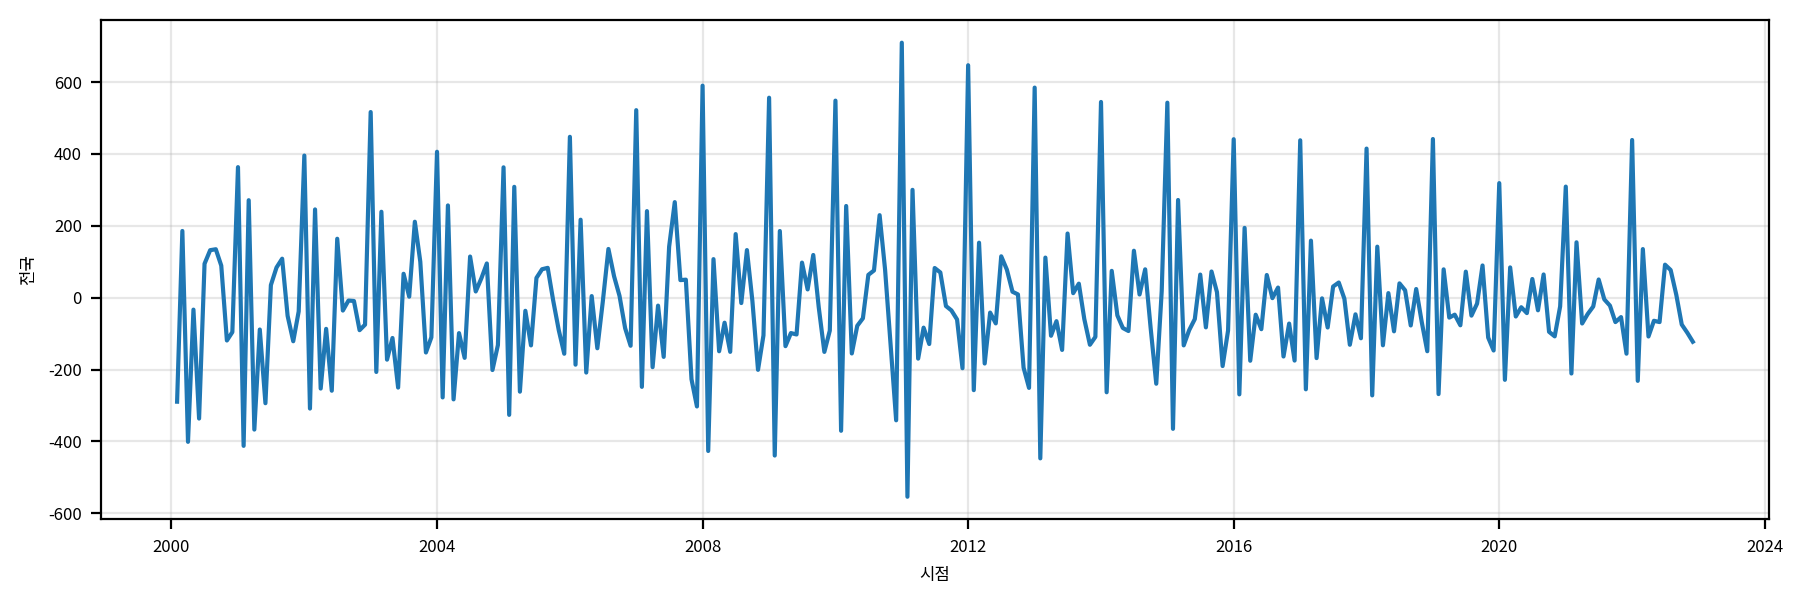

In [76]:
# 변수 지정
yname = '전국'

# 차분 및 정상성 검사
adf, diff_df = diff(df3, yname)
display(adf)
display(diff_df)

# 최소 차분 차수(d) 추출
d = adf.loc[adf["result"], "차수"].min()
display(d)

# ==============================
# 차분 결과 시각화
# ==============================
width_px = 1800
height_px = 600
rows = 1
cols = 1

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(
    rows,
    cols,
    figsize=figsize,
    dpi=my_dpi
)

sb.lineplot(
    data=diff_df,
    x=diff_df.index,
    y=yname,
    ax=ax
)

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()


📝ACf,PACF

In [77]:
def estimate_pq(acf_vals, pacf_vals, conf):
    q = next(
        (i for i, v in enumerate(acf_vals[1:], start=1) if abs(v) < conf),
        len(acf_vals)
    )
    p = next(
        (i for i, v in enumerate(pacf_vals[1:], start=1) if abs(v) < conf),
        len(pacf_vals)
    )
    return p-1, q-1


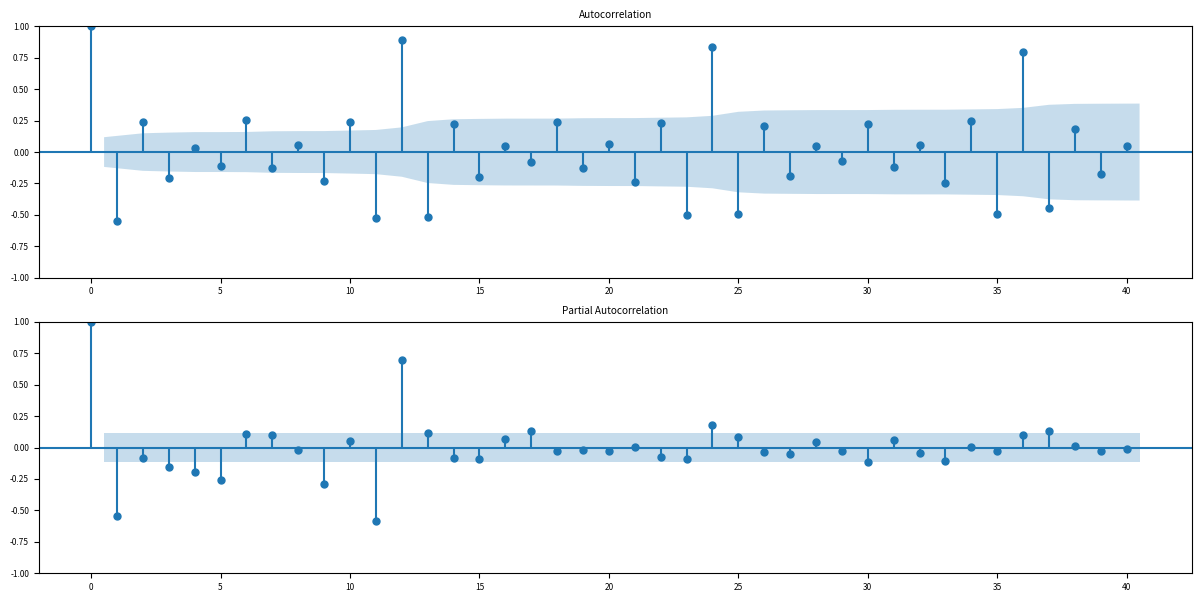

p=16,q=29


In [78]:
p,q = acf_pacf(diff_df, '전국')
print(f"p={p},q={q}")

📝최적모형 찾기

📝최종 모형 생성 및 결과 해석

In [ ]:
best_order = (
    int(best_model['p']),
    int(best_model['d']),
    int(best_model['q']),
    12

)

final_model = ARIMA(df3[yname], order = best_order, seasonal_order=s_best_order)
final_fit = final_model.fit()

cf, rdf, r, m,v=  arima_report(final_fit,df)

display(cdf)
display(rdf)
display(r)
display(m)
display(v)
